# Caculate B-V and V-R

## Load data and convert to ra,dec

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.xmatch import XMatch
from astropy.table import Table
dir=r'C:\Users\Shinr\Documents\temp\for study\astro\observation\task\M15_reduced'

def xy2radec(x,y,wcs):
    coords=wcs.pixel_to_world(x,y)
    return coords.ra.degree,coords.dec.degree

B_pd=pd.read_csv(Path(dir,'M15_B.csv'),sep=',',header=0,usecols=['x_fit','y_fit','mag_B'])
hdul=fits.open(Path(dir,'B.fits'))
hdr=hdul[0].header
B_wcs=WCS(hdr)
hdul.close()
B_pd['ra_B'],B_pd['dec_B']=xy2radec(B_pd['x_fit'],B_pd['y_fit'],B_wcs)
B_tb=Table.from_pandas(B_pd)

V_pd=pd.read_csv(Path(dir,'M15_V.csv'),sep=',',header=0,usecols=['x_fit','y_fit','mag_V'])
hdul=fits.open(Path(dir,'V.fits'))
hdr=hdul[0].header
V_wcs=WCS(hdr)
hdul.close()
V_pd['ra_V'],V_pd['dec_V']=xy2radec(V_pd['x_fit'],V_pd['y_fit'],V_wcs)
V_tb=Table.from_pandas(V_pd)

R_pd=pd.read_csv(Path(dir,'M15_R.csv'),sep=',',header=0,usecols=['x_fit','y_fit','mag_R'])
hdul=fits.open(Path(dir,'R.fits'))
hdr=hdul[0].header
R_wcs=WCS(hdr)
hdul.close()
R_pd['ra_R'],R_pd['dec_R']=xy2radec(R_pd['x_fit'],R_pd['y_fit'],R_wcs)
R_tb=Table.from_pandas(R_pd)

## Match tables

In [2]:
def remove_table_duplication(tb, colnames):
    for col in colnames:
        _, idx, counts = np.unique(tb[col], return_index=True, return_counts=True)
        fltr = np.isin(tb[col], tb[col][idx[counts==1]])
        tb = tb[fltr]
    return tb

BV_tb=XMatch.query(cat1=B_tb,cat2=V_tb,max_distance=1*u.arcsec,
                  colRA1='ra_B',colDec1='dec_B',
                  colRA2='ra_V',colDec2='dec_V')
BV_tb=remove_table_duplication(BV_tb,['ra_B','dec_B','ra_V','dec_V'])
BV_tb['B-V']=BV_tb['mag_B']-BV_tb['mag_V']

VR_tb=XMatch.query(cat1=V_tb,cat2=R_tb,max_distance=1*u.arcsec,
                  colRA1='ra_V',colDec1='dec_V',
                  colRA2='ra_R',colDec2='dec_R')
VR_tb=remove_table_duplication(VR_tb,['ra_V','dec_V','ra_R','dec_R'])
VR_tb['V-R']=VR_tb['mag_V']-VR_tb['mag_R']

BV_VR_tb=XMatch.query(cat1=BV_tb,cat2=VR_tb,max_distance=1*u.arcsec,
                      colRA1='ra_V',colDec1='dec_V',
                      colRA2='ra_R',colDec2='dec_R')
BV_VR_tb=remove_table_duplication(BV_VR_tb,['ra_B','dec_B','ra_V','dec_V','ra_R','dec_R'])

print(f'Matched {len(BV_tb)} stars for B-V colour, {len(BV_VR_tb)} stars for B-V vs V-R.')


Matched 1249 stars for B-V colour, 1212 stars for B-V vs V-R.


# Plot HR diagram and color color diagram

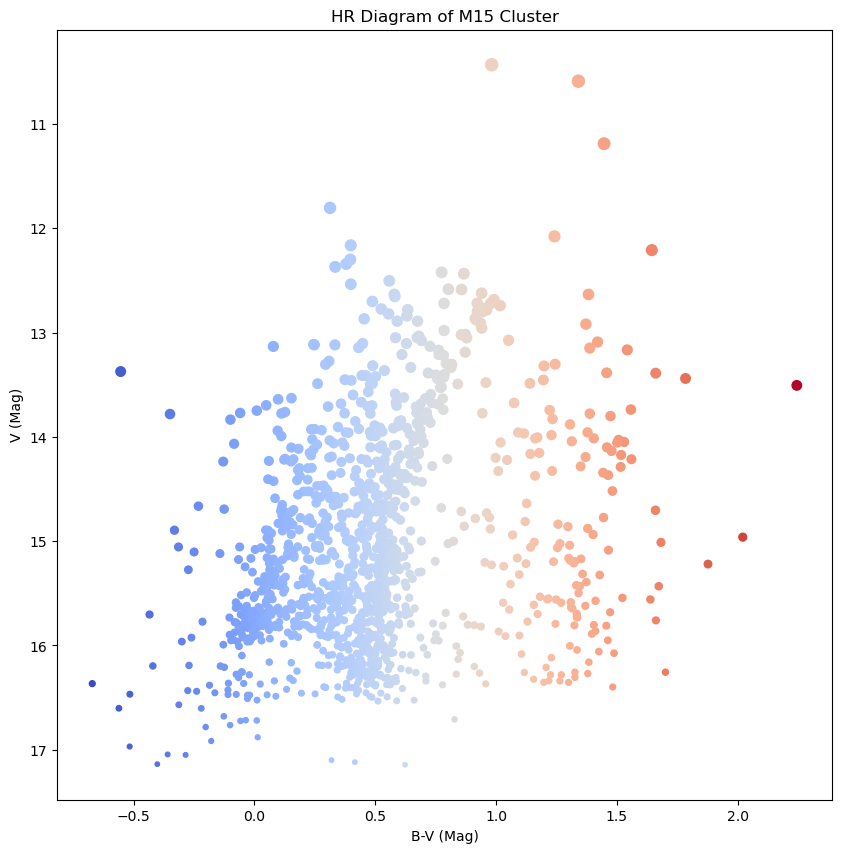

In [3]:
plt.figure(figsize=(10,10))
sizes = (BV_tb['mag_V'].max() - BV_tb['mag_V'] + 1) * 10
plt.scatter(BV_tb['B-V'],BV_tb['mag_V'],s=sizes, c=BV_tb['B-V'],cmap='coolwarm')
plt.xlabel('B-V (Mag)')
plt.ylabel('V (Mag)')
plt.title('HR Diagram of M15 Cluster')
plt.gca().invert_yaxis()
plt.show()

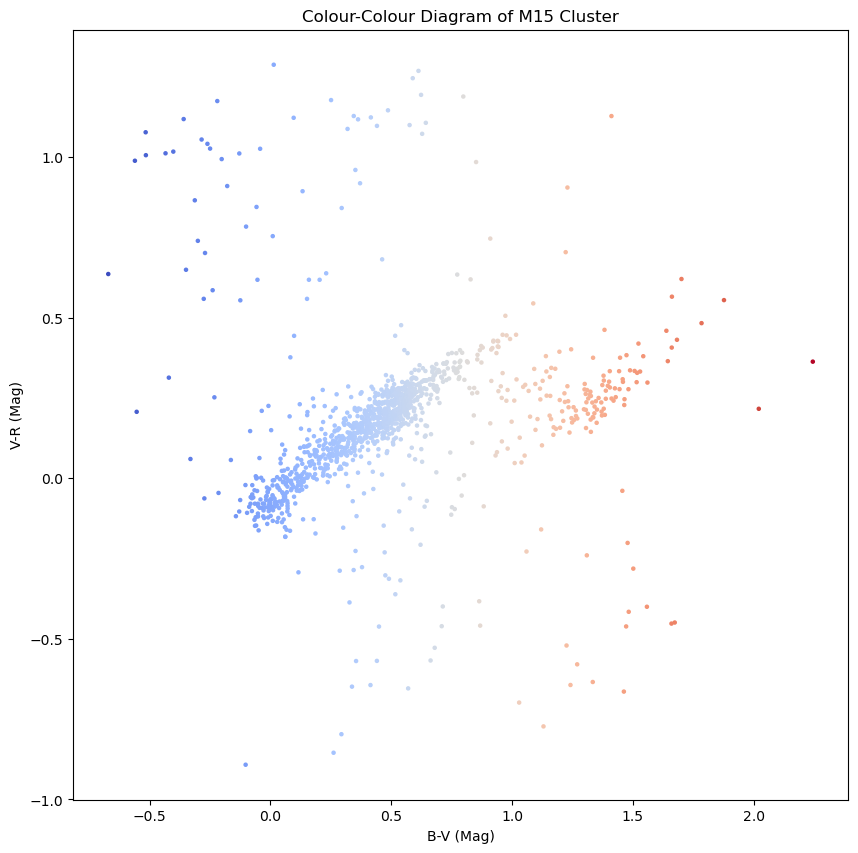

In [13]:
plt.figure(figsize=(10,10))
plt.scatter(BV_VR_tb['B-V'],BV_VR_tb['V-R'],s=5, c=BV_VR_tb['B-V'],cmap='coolwarm')
plt.xlabel('B-V (Mag)')
plt.ylabel('V-R (Mag)')
plt.title('Colour-Colour Diagram of M15 Cluster')
plt.show()

# Discard unwanted data

## Find clusters in data

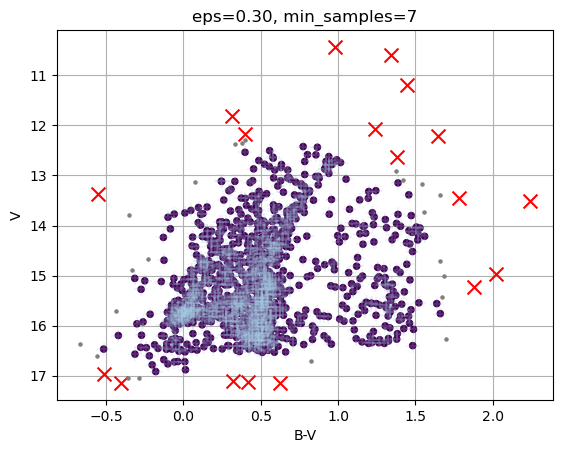

In [5]:
from sklearn.cluster import DBSCAN
bv=np.array([[x,y] for x,y in zip(BV_tb['B-V'],BV_tb['mag_V'])])
dbscan=DBSCAN(eps=0.3,min_samples=7)
dbscan.fit(bv)

core_mask=np.zeros_like(dbscan.labels_,dtype=bool)
core_mask[dbscan.core_sample_indices_]=True
anomalies_mask=dbscan.labels_==-1
non_core_mask=~(core_mask|anomalies_mask)

cores=dbscan.components_
anomalies=bv[anomalies_mask]
non_cores=bv[non_core_mask]
plt.scatter(cores[:,0],cores[:,1],c=dbscan.labels_[core_mask],marker='o',
            s=20)
plt.scatter(cores[:,0],cores[:,1],c=dbscan.labels_[core_mask],marker='+',
            s=100,cmap='Paired',alpha=0.2)
plt.scatter(anomalies[:,0],anomalies[:,1],c='r',marker='x',s=100)
plt.scatter(non_cores[:,0],non_cores[:,1],c='gray',marker='.',s=20)
plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
plt.xlabel('B-V')
plt.ylabel('V')
plt.grid()
plt.gca().set_axisbelow(True)
plt.gca().invert_yaxis()
plt.show()
BV_tb['HR diag labels']=dbscan.labels_

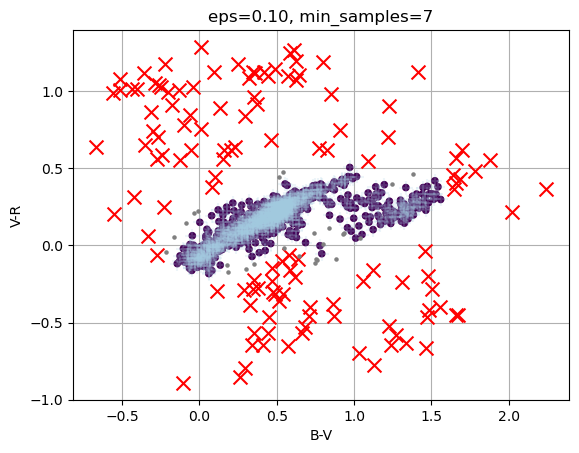

In [6]:
from sklearn.cluster import DBSCAN
bv_vr=np.array([[x,y] for x,y in zip(BV_VR_tb['B-V'],BV_VR_tb['V-R'])])
dbscan=DBSCAN(eps=0.1,min_samples=7)
dbscan.fit(bv_vr)

core_mask=np.zeros_like(dbscan.labels_,dtype=bool)
core_mask[dbscan.core_sample_indices_]=True
anomalies_mask=dbscan.labels_==-1
non_core_mask=~(core_mask|anomalies_mask)

cores=dbscan.components_
anomalies=bv_vr[anomalies_mask]
non_cores=bv_vr[non_core_mask]
plt.scatter(cores[:,0],cores[:,1],c=dbscan.labels_[core_mask],marker='o',
            s=20)
plt.scatter(cores[:,0],cores[:,1],c=dbscan.labels_[core_mask],marker='+',
            s=100,cmap='Paired',alpha=0.2)
plt.scatter(anomalies[:,0],anomalies[:,1],c='r',marker='x',s=100)
plt.scatter(non_cores[:,0],non_cores[:,1],c='gray',marker='.',s=20)
plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
plt.xlabel('B-V')
plt.ylabel('V-R')
plt.grid()
plt.gca().set_axisbelow(True)
plt.show()
BV_VR_tb['CM diag labels']=dbscan.labels_

## Identify cluster stars

In [7]:
fltr_HR=BV_tb['HR diag labels']!=-1
fltr_CM=BV_VR_tb['CM diag labels']!=-1
tb=XMatch.query(cat1=BV_tb[fltr_HR],cat2=BV_VR_tb[fltr_CM],max_distance=1*u.arcsec,
                  colRA1='ra_V',colDec1='dec_V',
                  colRA2='ra_R',colDec2='dec_R')
tb=tb[['x_fit','y_fit','ra_V','dec_V','mag_B','mag_V','mag_R','B-V','V-R','HR diag labels','CM diag labels']]
tb=remove_table_duplication(tb,['ra_V','dec_V'])

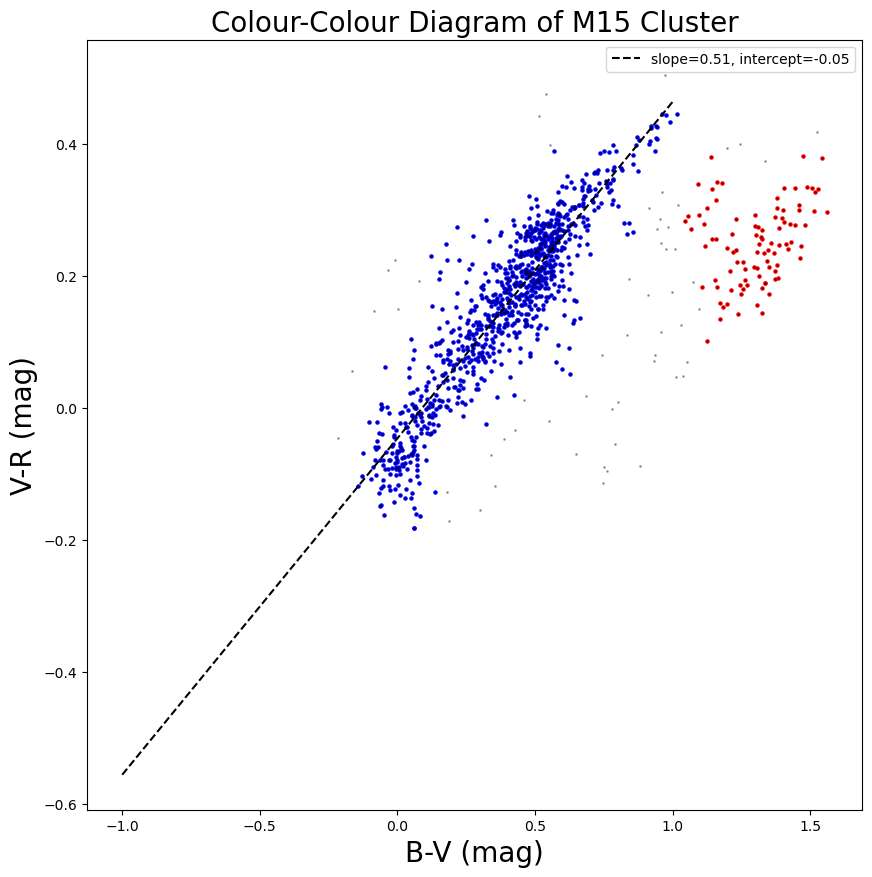

In [18]:
from sklearn.linear_model import LinearRegression
bv_vr=np.array([[x,y] for x,y in zip(tb['B-V'],tb['V-R'])])
dbscan=DBSCAN(eps=0.06,min_samples=7)
dbscan.fit(bv_vr)

core_mask=np.zeros_like(dbscan.labels_,dtype=bool)
core_mask[dbscan.core_sample_indices_]=True
anomalies_mask=dbscan.labels_==-1
non_core_mask=~(core_mask|anomalies_mask)

cores=dbscan.components_
anomalies=bv_vr[anomalies_mask]
non_cores=bv_vr[non_core_mask]
tb['flag']=dbscan.labels_
f0=tb['flag']==0
reg0=LinearRegression().fit(tb[f0]['B-V'].reshape(-1,1),tb[f0]['V-R'].reshape(-1,1))
coef0,intercept0=reg0.coef_[0][0],reg0.intercept_[0]
f1=tb['flag']==1
# reg0=LinearRegression().fit(tb[f1]['B-V'].reshape(-1,1),tb[f1]['V-R'].reshape(-1,1))
# coef1,intercept1=reg0.coef_[0][0],reg0.intercept_[0]
plt.figure(figsize=(10,10))
plt.scatter(tb[f0]['B-V'],tb[f0]['V-R'],c='blue',s=5)
plt.scatter(tb[f1]['B-V'],tb[f1]['V-R'],c='red',s=5)
plt.scatter(tb['B-V'],tb['V-R'],c='black',alpha=0.3,s=1)
x=np.linspace(-1,1,100)
plt.plot(x,coef0*x+intercept0,c='black',ls='--',label=f'slope={coef0:.2f}, intercept={intercept0:.2f}')
#plt.plot(x,coef1*x+intercept1,c='black',ls='--',label=f'slope={coef1:.2f}, intercept={intercept1:.2f}')
plt.xlabel('B-V (mag)',size=20)
plt.ylabel('V-R (mag)',size=20)
plt.title('Colour-Colour Diagram of M15 Cluster',size=20)
plt.legend()
plt.show()



# Replot HR diagram

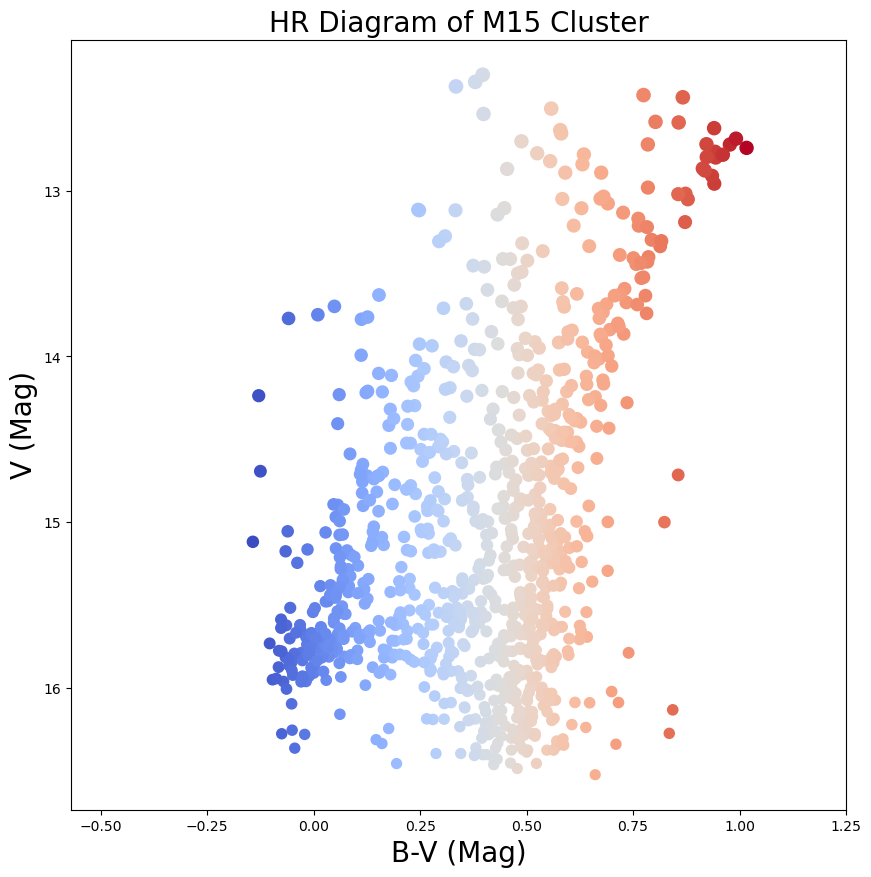

In [14]:
plt.figure(figsize=(10,10))
sizes =(tb[f0]['mag_V'].max() - tb[f0]['mag_V'] + 5) * 10
plt.scatter(tb[f0]['B-V'],tb[f0]['mag_V'],s=sizes, c=tb[f0]['B-V'],cmap='coolwarm')
#plt.scatter(tb[f1]['B-V'],tb[f1]['mag_V'],s=1, c='gray')
plt.xlim(-0.57,1.25)
plt.xlabel('B-V (Mag)',size=20)
plt.ylabel('V (Mag)',size=20)
plt.title('HR Diagram of M15 Cluster',size=20)
plt.gca().invert_yaxis()
plt.show()

We can see the evolution track of M15 cluster stars which is nearly vertical in the HR diagram. There are some stars that moves upward from the red giatn branch.

# Discussions

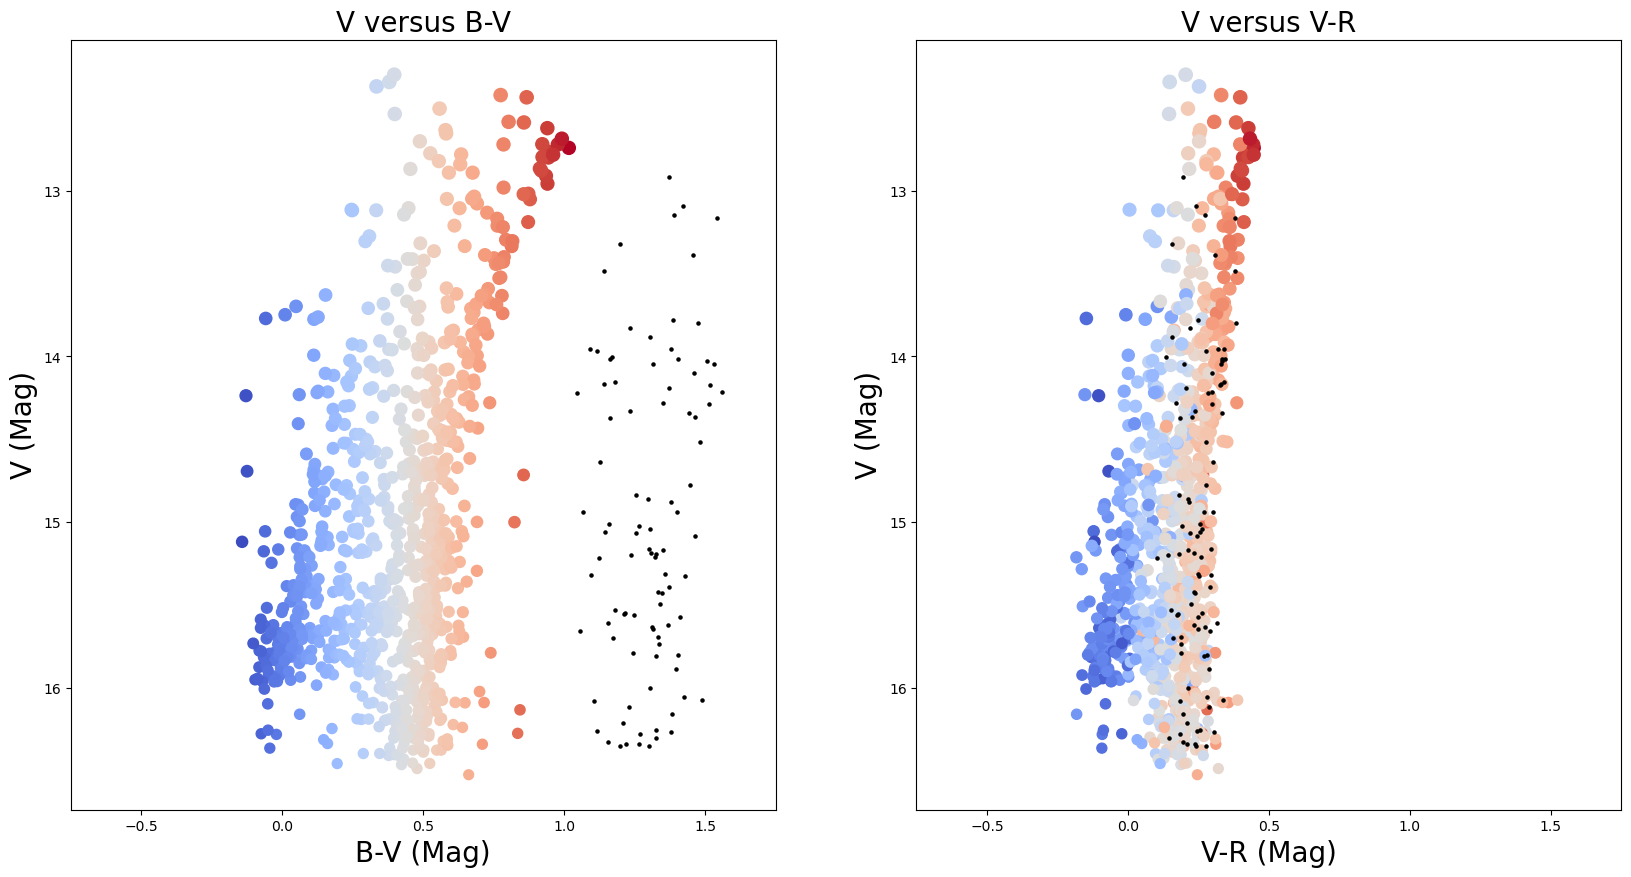

In [23]:
plt.figure(figsize=(20,10))
plt.subplot(121)
sizes =(tb[f0]['mag_V'].max() - tb[f0]['mag_V'] + 5) * 10
plt.scatter(tb[f0]['B-V'],tb[f0]['mag_V'],s=sizes, c=tb[f0]['B-V'],cmap='coolwarm')
plt.scatter(tb[f1]['B-V'],tb[f1]['mag_V'],s=5, c='black')
plt.xlim(-0.75,1.75)
plt.xlabel('B-V (Mag)',size=20)
plt.ylabel('V (Mag)',size=20)
plt.title('V versus B-V',size=20)
plt.gca().invert_yaxis()

plt.subplot(122)
sizes =(tb[f0]['mag_V'].max() - tb[f0]['mag_V'] + 5) * 10
plt.scatter(tb[f0]['V-R'],tb[f0]['mag_V'],s=sizes, c=tb[f0]['B-V'],cmap='coolwarm')
plt.scatter(tb[f1]['V-R'],tb[f1]['mag_V'],s=5, c='black')
plt.xlim(-0.75,1.75)
plt.xlabel('V-R (Mag)',size=20)
plt.ylabel('V (Mag)',size=20)
plt.title('V versus V-R',size=20)
plt.gca().invert_yaxis()

plt.show()

In HR diagram, there's a group of points that are redder and more diffuse, and follow a track parallel to the cluster stars.
After removing the red-labeled points in the color-color diagram, the redder group in the HR diagram vanishes.
However, in V versus V-R diagram, the red-labeled points have approximately the same V-R value as the cluster stars.

In [34]:
B_mean1,B_median1,B_std1=np.mean(tb[f1]['mag_B']),np.median(tb[f1]['mag_B']),np.std(tb[f1]['mag_B'])
V_mean1,V_median1,V_std1=np.mean(tb[f1]['mag_V']),np.median(tb[f1]['mag_V']),np.std(tb[f1]['mag_V'])
R_mean1,R_median1,R_std1=np.mean(tb[f1]['mag_R']),np.median(tb[f1]['mag_R']),np.std(tb[f1]['mag_R'])


B_mean0,B_median0,B_std0=np.mean(tb[f0]['mag_B']),np.median(tb[f0]['mag_B']),np.std(tb[f0]['mag_B'])
V_mean0,V_median0,V_std0=np.mean(tb[f0]['mag_V']),np.median(tb[f0]['mag_V']),np.std(tb[f0]['mag_V'])
R_mean0,R_median0,R_std0=np.mean(tb[f0]['mag_R']),np.median(tb[f0]['mag_R']),np.std(tb[f0]['mag_R'])

print(f'\t    \t Special stars \t Normal stars \
    \n\tB_Mean  \t {B_mean1:.2f} \t {B_mean0:.2f}   \
    \n\tB_Median \t {B_median1:.2f} \t {B_median0:.2f}  \
    \n\tB_Std   \t {B_std1:.2f} \t {B_std0:.2f}')
print(f'\t    \t Special stars \t Normal stars \
    \n\tV_Mean  \t {V_mean1:.2f} \t {V_mean0:.2f}   \
    \n\tV_Median \t {V_median1:.2f} \t {V_median0:.2f}  \
    \n\tV_Std   \t {V_std1:.2f} \t {V_std0:.2f}')
print(f'\t    \t Special stars \t Normal stars \
    \n\tR_Mean  \t {R_mean1:.2f} \t {R_mean0:.2f}   \
    \n\tR_Median \t {R_median1:.2f} \t {R_median0:.2f}  \
    \n\tR_Std   \t {R_std1:.2f} \t {R_std0:.2f}')

	    	 Special stars 	 Normal stars     
	B_Mean  	 16.29 	 15.49       
	B_Median 	 16.42 	 15.68      
	B_Std   	 0.90 	 0.87
	    	 Special stars 	 Normal stars     
	V_Mean  	 14.99 	 15.10       
	V_Median 	 15.16 	 15.36      
	V_Std   	 0.92 	 0.93
	    	 Special stars 	 Normal stars     
	R_Mean  	 14.74 	 14.95       
	R_Median 	 14.87 	 15.23      
	R_Std   	 0.93 	 0.99


c:\Users\Shinr\miniconda3\envs\astro\Lib\site-packages\numpy\_core\fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


The red-labeled points have higher B magnitudes. Their V and R magnitudes are the similar to cluster stars.

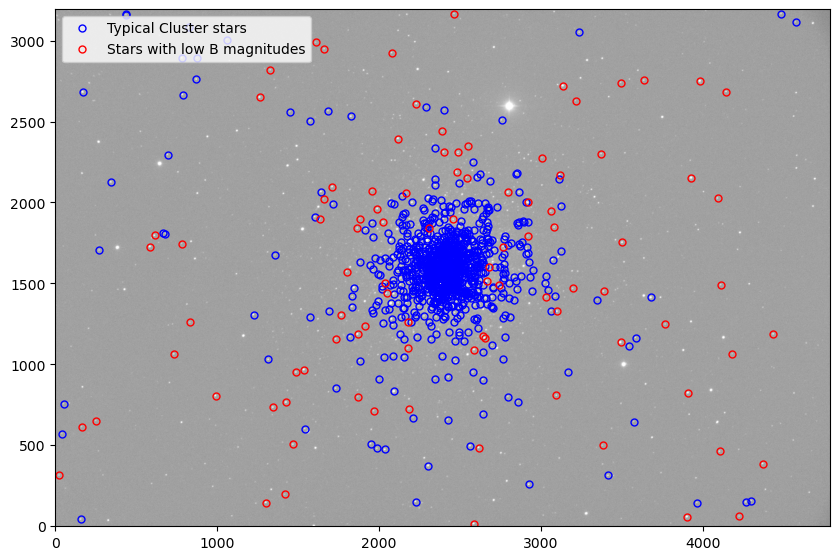

In [12]:
from astropy.visualization import simple_norm
hdul=fits.open(Path(dir,'B.fits'))
img=hdul[0].data
hdr=hdul[0].header
wcs=WCS(hdr)
hdul.close()
norm=simple_norm(img,stretch='asinh',percent=99.5)
plt.figure(figsize=(10,10))
plt.imshow(img,origin='lower',cmap='gray',norm=norm,alpha=0.5)
plt.plot(tb[f0]['x_fit'],tb[f0]['y_fit'],marker='o',mec='blue',ls='none',mfc='none',markersize=5,label='Typical Cluster stars')
plt.plot(tb[f1]['x_fit'],tb[f1]['y_fit'],marker='o',mec='red',ls='none',mfc='none',markersize=5,label='Stars with low B magnitudes')
plt.legend(loc='upper left')
plt.show()